# Santander Customer Transaction Prediction

Бинарная классификация клиентов для соревнования Kaggle.

**Целевая метрика:** ROC-AUC


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

## Загрузка данных


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

## Первичный анализ данных


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), str(1)
memory usage: 308.2 MB


In [6]:
train.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


## Подготовка данных


In [3]:
features = [c for c in train.columns if c.startswith('var_')]
X = train[features]
y = train['target']
X_test = test[features]
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,stratify=y,random_state=123)

## Распределение целевой переменной


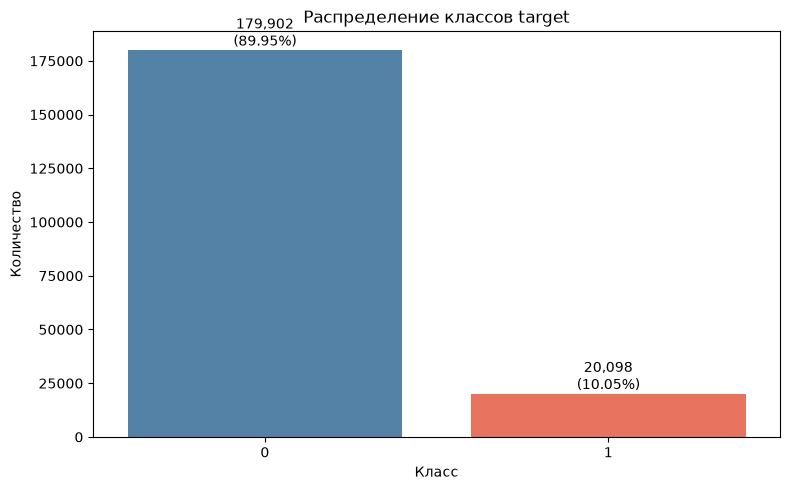

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

y = train['target']

counts = y.value_counts().sort_index()
percentages = y.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=counts.index.astype(str),
    y=counts.values,
    hue=counts.index.astype(str),
    palette=['steelblue', 'tomato'],
    legend=False
)

for i, count in enumerate(counts.values):
    ax.text(
        i,
        count,
        f'{count:,}\n({percentages.iloc[i]:.2f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Распределение классов target')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

## Логистическая регрессия без настройки


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=123,max_iter=1000)

log_reg.fit(X_train, y_train)
predictions = log_reg.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission['target'] = predictions
submission.to_csv('result/log_reg_clean.csv',index=False)


## Логистическая регрессия с настройками


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, uniform
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(
        random_state=123,
        max_iter=5000,
        solver='saga'
    ))
])
param_distributions = [
    {
        'log_reg__penalty': ['l1', 'l2'],
        'log_reg__C': loguniform(1e-4, 1e2),
        'log_reg__class_weight': [None, 'balanced']
    },
    {
        'log_reg__penalty': ['elasticnet'],
        'log_reg__C': loguniform(1e-4, 1e2),
        'log_reg__l1_ratio': uniform(0, 1),
        'log_reg__class_weight': [None, 'balanced']
    }
]
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True,
    return_train_score=False
)

random_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(random_search.best_params_)

print("Лучший средний Average Precision на CV:")
print(random_search.best_score_)

best_log_reg = random_search.best_estimator_

predictions = best_log_reg.predict_proba(X_test)[:, 1]

submission = sample_submission.copy()
submission['target'] = predictions
submission.to_csv('result/log_reg_l1_l2_elasticnet.csv', index=False)

## Дерево решений без настройки


> **Public Score:** 0.56217


In [ ]:
from sklearn.tree import DecisionTreeClassifier

Tree = DecisionTreeClassifier(random_state=42)
Tree.fit(X_train, y_train)
predictions = Tree.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission['target'] = predictions
submission.to_csv('result/decision_tree_clean.csv',index=False)

## Дерево решений с настройками


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
Tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 12],
    'min_samples_split': [2,10,50],
    'min_samples_leaf': [1,10,50,100],
    'max_features': [None, 'sqrt']
}
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    estimator=Tree,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_

print("Лучшие параметры:")
print(grid_search.best_params_)

print("Лучший средний ROC-AUC на CV:")
print(grid_search.best_score_)

predictions = best_tree.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission['target'] = predictions
submission.to_csv('result/decision_tree_update.csv',index=False)

## Бустинг без настройки


### CatBoost

**Public Score:** 0.89574


In [ ]:
from catboost import CatBoostClassifier
Yandex = CatBoostClassifier(task_type='GPU')

Yandex.fit(X_train,y_train,early_stopping_rounds=200,use_best_model=True,verbose=False)
predictions = Yandex.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission['target'] = predictions  
submission.to_csv('result/catboost_clean.csv',index=False)

### LightGBM


In [ ]:
from lightgbm import LGBMClassifier

GMB = LGBMClassifier(random_state=42,n_jobs=-1,verbosity=-1)
GMB.fit(X_train,y_train,early_stopping_rounds=200,use_best_model=True,verbose=False)
predictions = GMB.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission['target'] = predictions
submission.to_csv('result/lightgbm_clean.csv',index=False)

### XGBoost


In [ ]:
from xgboost import XGBClassifier

XGB = XGBClassifier(random_state=42,n_jobs=-1,verbosity=0)
XGB.fit(X_train, y_train)
predictions = XGB.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission["target"] = predictions
submission.to_csv("result/xgboost_clean.csv",index=False)

## Бустинг с настройками


### CatBoost


In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="PRAUC",
    iterations=5000,
    learning_rate=0.03,
    depth=12,
    l2_leaf_reg=10,
    random_seed=42,
    task_type="GPU",
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=300,
    use_best_model=True
)

predictions = model.predict_proba(X_test)[:, 1]

submission = sample_submission.copy()
submission["target"] = predictions
submission.to_csv("result/catboost_strong_baseline.csv", index=False)


### XGBoost


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="gpu",             
    random_state=42,
    verbosity=0,
    n_jobs=1
)

param_grid = {
    "n_estimators": [600, 1000],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.6, 0.8],
    "reg_lambda": [1, 10]
}

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

grid_search = GridSearchCV(estimator=xgb_model,param_grid=param_grid,scoring="average_precision",cv=cv,n_jobs=-1,verbose=2,refit=True)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

print("Лучший средний PR-AUC / Average Precision на CV:")
print(grid_search.best_score_)

best_boosting = grid_search.best_estimator_
predictions = best_boosting.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission["target"] = predictions

submission.to_csv("result/boosting_xgboost_update.csv",index=False)

### LightGBM


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

lgbm_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    device_type="gpu",
    random_state=42,
    verbosity=-1,
    n_jobs=1,
    subsample_freq=1
)

param_grid = {
    "n_estimators": [600, 1000],
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.03, 0.1],
    "min_child_samples": [10, 30],
    "subsample": [0.6, 0.8],
    "reg_lambda": [1, 10]
}
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_search.best_params_)
print("Лучший средний PR-AUC / Average Precision на CV:")
print(grid_search.best_score_)

best_boosting = grid_search.best_estimator_

predictions = best_boosting.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission["target"] = predictions
submission.to_csv("result/boosting_lightgbm_update.csv",index=False)